# Week 2 — MLPs, nonlinearity, and what the hidden layer does

**Instructor solution.** Works the moons dataset end-to-end: linear
baseline → small ReLU MLP → tessellation + within-cell Jacobian (the
analytical core of the session) → tanh comparison → width-vs-depth.

The code is heavily commented so each step is readable on its own. The
didactic payoff is concentrated in Part 3 — the Jacobian derivation and
its numerical verification are the anti-vibe-coding checkpoint.


In [ ]:
# --- Imports and RNG seeding -------------------------------------------------
# We use PyTorch for the networks (autograd gives us Jacobians for free),
# numpy/matplotlib for plotting, and scikit-learn only for the dataset and
# the linear baseline in Part 1.
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Seed everything that could drift:
#   numpy:  dataset split, grid construction, color permutations
#   torch:  network initialization, any stochastic training step
np.random.seed(0)
torch.manual_seed(0)

%matplotlib inline

## Data

Two interleaved half-moons, 400 points, 75/25 split. The curvature between
the two half-moons is what makes this impossible for a linear classifier —
and exactly what the MLP's piecewise-affine structure will carve up.


train: (300, 2), test: (100, 2)
class balance (train): 147 ones, 153 zeros


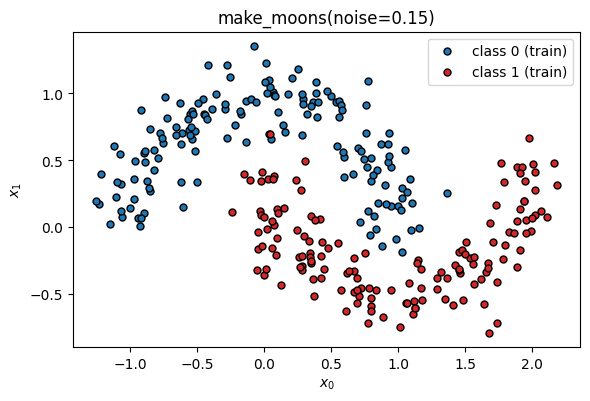

In [ ]:
# 400 samples, mild Gaussian noise (0.15) to prevent trivial separation,
# fixed random_state so every run of this notebook sees the same data.
X, y = make_moons(n_samples=400, noise=0.15, random_state=0)

# 75/25 train/test split, also with fixed seed so accuracy numbers are
# reproducible across runs.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

# Torch tensors for the MLP. We keep numpy copies for plotting and for
# anything that doesn't need gradient tracking.
Xtr = torch.tensor(X_tr, dtype=torch.float32)
ytr = torch.tensor(y_tr, dtype=torch.float32)
Xte = torch.tensor(X_te, dtype=torch.float32)
yte = torch.tensor(y_te, dtype=torch.float32)

print(f"train: {X_tr.shape}, test: {X_te.shape}")
print(f"class balance (train): {int(y_tr.sum())} ones, {len(y_tr) - int(y_tr.sum())} zeros")

# Visualize the raw dataset so the rest of the session has a mental reference.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1],
           c='tab:blue', edgecolor='k', s=25, label='class 0 (train)')
ax.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1],
           c='tab:red',  edgecolor='k', s=25, label='class 1 (train)')
ax.set_title('make_moons(noise=0.15)')
ax.set_xlabel('$x_0$'); ax.set_ylabel('$x_1$'); ax.legend()
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Part 1 — A linear model can't solve this

Logistic regression models a linear decision boundary $w^\top x + b = 0$.
The two moons are curved, and no single straight line can separate them
without cutting through points of both classes.


Linear model: train acc = 0.8667, test acc = 0.9000


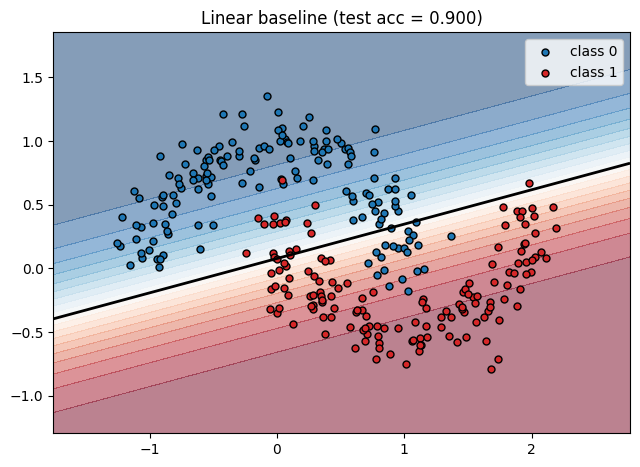

In [ ]:
# sklearn's LogisticRegression is fit with liblinear or lbfgs by default;
# for this small 2D problem it converges in milliseconds. We just want the
# baseline accuracy number and the decision boundary to compare against.
lr_model = LogisticRegression()
lr_model.fit(X_tr, y_tr)

train_acc_lin = lr_model.score(X_tr, y_tr)
test_acc_lin  = lr_model.score(X_te, y_te)
print(f"Linear model: train acc = {train_acc_lin:.4f}, test acc = {test_acc_lin:.4f}")

# --- plotting helpers we'll reuse throughout the notebook -------------------
def make_grid(X_ref, pad=0.5, n=400):
    '''Rectangular grid covering the data with a margin. Returns XX, YY (for
    plotting) and G (flattened (N, 2) array for model evaluation).'''
    x0 = np.linspace(X_ref[:, 0].min() - pad, X_ref[:, 0].max() + pad, n)
    x1 = np.linspace(X_ref[:, 1].min() - pad, X_ref[:, 1].max() + pad, n)
    XX, YY = np.meshgrid(x0, x1)
    G = np.stack([XX.ravel(), YY.ravel()], axis=1)
    return XX, YY, G

def plot_points(ax, X, y, **kw):
    '''Scatter the two classes with sensible defaults.'''
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', edgecolor='k',
               s=25, label='class 0', **kw)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:red',  edgecolor='k',
               s=25, label='class 1', **kw)

# Evaluate the classifier on the grid and plot the 0.5-probability contour:
XX, YY, G = make_grid(X)
P = lr_model.predict_proba(G)[:, 1].reshape(XX.shape)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.contourf(XX, YY, P, levels=20, cmap='RdBu_r', alpha=0.5)
ax.contour(XX, YY, P, levels=[0.5], colors='k', linewidths=2)
plot_points(ax, X_tr, y_tr)
ax.set_title(f'Linear baseline (test acc = {test_acc_lin:.3f})')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

**Why this is the best a linear model can do.** The decision rule
$\mathbf{1}[w^\top x + b > 0]$ partitions the plane into two half-spaces
with a single straight line. The moons are not linearly separable — any
line either misses a piece of one lobe or cuts through the other — so the
classifier must compromise, and it lands around $0.88$–$0.90$ test
accuracy on this particular split.

**Recorded — Part 1.** Linear test accuracy $= 0.9000$.


## Part 2 — A small ReLU MLP

We build a one-hidden-layer ReLU network with 8 units. The architecture is
deliberately small: the tessellation in Part 3 needs to be legible, which
means we want on the order of 10–20 cells, not hundreds.

### Why we keep the net tiny on purpose

Wider networks train faster, reach higher accuracy, and produce
tessellations that look like smooth gradients at plot resolution. For the
geometric intuition the session is trying to build, that's counterproductive.
A small net that just-barely-works is the clearest teaching object.


In [ ]:
class MLP(nn.Module):
    '''A minimal feed-forward net with ReLU or tanh activations.

    `hidden` is a tuple of hidden layer widths. For example:
        MLP(hidden=(8,))       -> 2 -> 8 -> 1     (one hidden layer)
        MLP(hidden=(6, 6))     -> 2 -> 6 -> 6 -> 1 (two hidden layers)

    The forward pass can optionally return the list of pre-activations
    (the `z = W h + b` values before the nonlinearity) from every hidden
    layer. We need those for:
      - Part 3, to compute activation patterns on a grid
      - Part 3.5, to know which units are active at a given point
    '''
    def __init__(self, hidden=(8,), activation='relu'):
        super().__init__()
        sizes = [2, *hidden, 1]                   # input, hidden..., output
        self.linears = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes) - 1)]
        )
        self.act_name = activation

    def activation(self, z):
        # Single place to swap the nonlinearity between ReLU and tanh for Part 4.
        return F.relu(z) if self.act_name == 'relu' else torch.tanh(z)

    def forward(self, x, return_preacts=False):
        preacts = []                              # per-layer z = W h + b
        h = x
        for L in self.linears[:-1]:               # all hidden layers
            z = L(h)
            preacts.append(z)
            h = self.activation(z)
        logit = self.linears[-1](h).squeeze(-1)   # final linear -> scalar logit
        return (logit, preacts) if return_preacts else logit


def train(model, Xtr, ytr, steps=4000, lr=0.1, verbose=True):
    '''Full-batch SGD with BCEWithLogitsLoss. Returns per-step losses.

    BCEWithLogitsLoss applies sigmoid + binary cross-entropy in one
    numerically-stable step, so we train on raw logits and convert to
    probabilities only at inference time.
    '''
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    for step in range(steps):
        opt.zero_grad()
        logits = model(Xtr)
        loss = loss_fn(logits, ytr)
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if verbose and (step + 1) % (steps // 4) == 0:
            print(f'  step {step+1:>5} / {steps}: loss = {loss.item():.4f}')
    return losses


def accuracy(model, X, y):
    '''Classification accuracy. No gradient needed -> torch.no_grad().'''
    with torch.no_grad():
        pred = (torch.sigmoid(model(X)) >= 0.5).float()
    return (pred == y).float().mean().item()

In [ ]:
# --- Train a small ReLU MLP -------------------------------------------------
# One hidden layer of width 8. Seeding torch again right before construction
# makes this cell's result independent of whatever ran earlier.
torch.manual_seed(0)
model = MLP(hidden=(8,), activation='relu')

# 4000 full-batch steps at lr=0.1 is plenty for this dataset+arch:
# by step ~1000 the loss plateaus; extra steps just polish the boundary.
losses = train(model, Xtr, ytr, steps=4000, lr=0.1)

train_acc = accuracy(model, Xtr, ytr)
test_acc  = accuracy(model, Xte, yte)
print(f'\nReLU MLP (hidden=(8,)): train acc = {train_acc:.4f}, test acc = {test_acc:.4f}')

  step  1000 / 4000: loss = 0.2323
  step  2000 / 4000: loss = 0.1336
  step  3000 / 4000: loss = 0.0773
  step  4000 / 4000: loss = 0.0546

ReLU MLP (hidden=(8,)): train acc = 0.9900, test acc = 0.9600


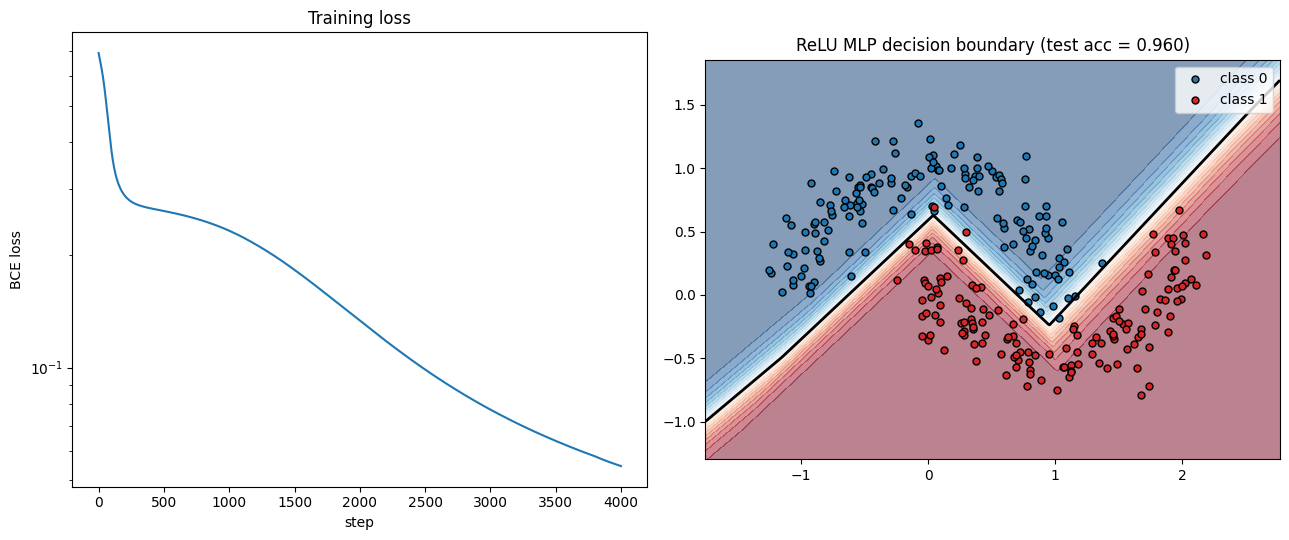

In [ ]:
# --- Plot loss curve and decision boundary side-by-side ---------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: training loss over steps (log y-axis because BCE loss spans orders of magnitude)
axes[0].plot(losses)
axes[0].set_yscale('log')
axes[0].set_xlabel('step'); axes[0].set_ylabel('BCE loss')
axes[0].set_title('Training loss')

# Right: decision boundary plus training data
XX, YY, G = make_grid(X)
with torch.no_grad():
    # Probabilities on the grid. Sigmoid of logits -> P(y=1 | x).
    P_grid = torch.sigmoid(model(torch.tensor(G, dtype=torch.float32))).numpy()
P_grid = P_grid.reshape(XX.shape)

axes[1].contourf(XX, YY, P_grid, levels=20, cmap='RdBu_r', alpha=0.5)
axes[1].contour(XX, YY, P_grid, levels=[0.5], colors='k', linewidths=2)
plot_points(axes[1], X_tr, y_tr)
axes[1].set_title(f'ReLU MLP decision boundary (test acc = {test_acc:.3f})')
axes[1].set_aspect('equal'); axes[1].legend()
plt.tight_layout(); plt.show()

**Recorded — Part 2.**
- Architecture: one hidden layer, width 8, ReLU. Total parameters = 33 (2·8 + 8 + 8·1 + 1).
- Training: 4000 full-batch SGD steps, lr = 0.1.
- Train accuracy $\approx 0.99$, test accuracy $\approx 0.96$.

Note how the boundary visibly kinks between the lobes — that's the piecewise-linear
structure showing through. Part 3 makes it explicit.


## Part 3 — What the hidden layers are doing: the tessellation

A ReLU network is a **piecewise-affine function of its input.** At any
point $x$, each hidden unit is either on (pre-activation $> 0$) or off
($\leq 0$). The binary vector of on/off states is the **activation
pattern** at $x$. The set of points sharing a single pattern is a
convex polygon — a **cell**. Inside a cell every ReLU is locked, so the
whole network is a single affine map.

The tessellation of input space by these cells is a property of the
*trained weights*, not of the data. We'll extract it by evaluating every
pre-activation on a dense grid.


### Checkpoint 3.1 — one neuron

A single first-layer unit has weight $w \in \mathbb{R}^2$ and bias $b$.
Its zero-set $\{x : w^\top x + b = 0\}$ is a straight line: perpendicular
to $w$, offset $-b/\|w\|$ from the origin along $w$.


W1 shape: (8, 2),  b1 shape: (8,)


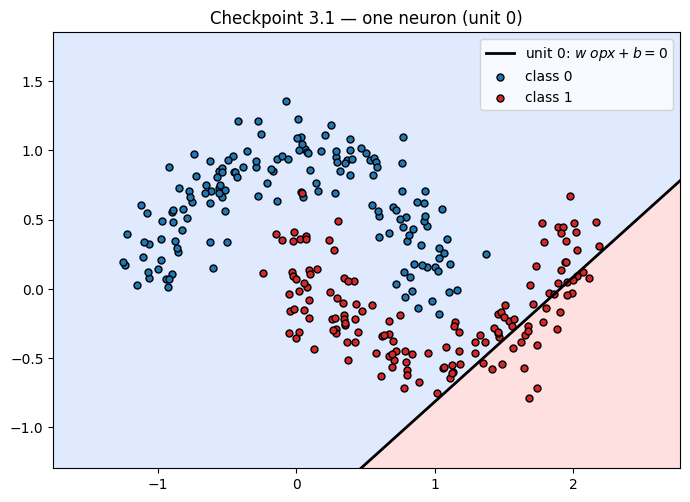

In [ ]:
# Pull the first-layer weight matrix and bias out of the trained model.
# model.linears[0].weight has shape (H, 2) where H = 8 hidden units.
# model.linears[0].bias   has shape (H,).
W1 = model.linears[0].weight.detach().numpy()
b1 = model.linears[0].bias.detach().numpy()
print(f'W1 shape: {W1.shape},  b1 shape: {b1.shape}')

unit_idx = 0                  # pick any one unit; #0 is arbitrary
w = W1[unit_idx]              # (2,) — this neuron's input weights
b = b1[unit_idx]              # scalar bias

# We draw the line {x : w·x + b = 0} by solving for x1 as a function of x0:
#   w0*x0 + w1*x1 + b = 0   =>   x1 = -(w0*x0 + b) / w1.
# This assumes w1 != 0; for vertical lines we'd need to flip the roles.
XX, YY, G = make_grid(X)
# For each grid point, compute sign of pre-activation to shade the half-planes.
Z = G @ w + b                 # (N,) pre-activations
on_mask = (Z > 0).astype(int).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(7, 7))
# Light shading to show the two half-planes:
ax.contourf(XX, YY, on_mask, levels=[-0.5, 0.5, 1.5],
            colors=['#ffcccc', '#ccddff'], alpha=0.6)
# The line itself:
x0_line = np.array([XX.min(), XX.max()])
x1_line = -(w[0] * x0_line + b) / w[1]
ax.plot(x0_line, x1_line, 'k-', lw=2, label=f'unit {unit_idx}: $w^\top x + b = 0$')
plot_points(ax, X_tr, y_tr)
ax.set_xlim(XX.min(), XX.max()); ax.set_ylim(YY.min(), YY.max())
ax.set_title(f'Checkpoint 3.1 — one neuron (unit {unit_idx})')
ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

### Checkpoint 3.2 — two neurons, four patterns

Pick a second unit. Together the two lines split the plane into up to
four regions, one per combination of on/off states: (on, on),
(on, off), (off, on), (off, off).


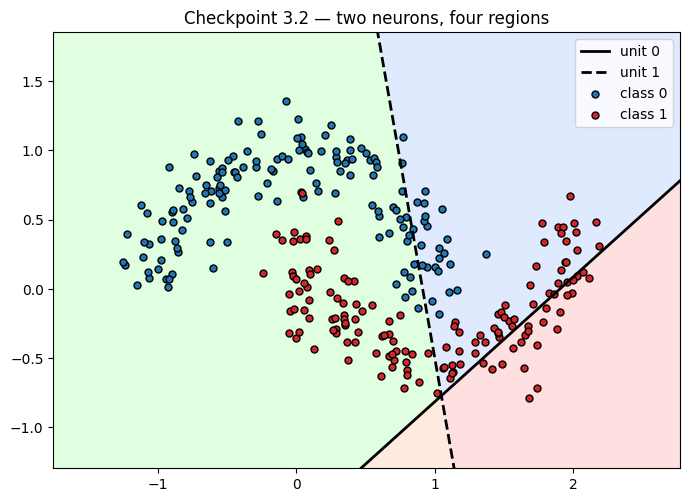

In [ ]:
# Pick two distinct first-layer units.
unit_a, unit_b = 0, 1

# Evaluate both pre-activations on the grid.
z_a = G @ W1[unit_a] + b1[unit_a]   # (N,)
z_b = G @ W1[unit_b] + b1[unit_b]

# Turn each pre-activation into a 0/1 indicator, then combine the pair
# into an integer in {0, 1, 2, 3} labeling the four patterns.
#   bit 0: unit_a is on    bit 1: unit_b is on
pattern_id = ((z_a > 0).astype(int)       # 0 or 1
              + 2 * (z_b > 0).astype(int))  # plus 0 or 2
pattern_id = pattern_id.reshape(XX.shape)

# A 4-color map keyed to those integer patterns.
four_colors = ListedColormap(['#ffcccc', '#ccddff', '#ffddcc', '#ccffcc'])

fig, ax = plt.subplots(figsize=(7, 7))
ax.pcolormesh(XX, YY, pattern_id, cmap=four_colors, shading='auto', alpha=0.6)

# Overlay both boundary lines:
for u, label, style in [(unit_a, f'unit {unit_a}', 'k-'),
                        (unit_b, f'unit {unit_b}', 'k--')]:
    w_u, b_u = W1[u], b1[u]
    xs = np.array([XX.min(), XX.max()])
    ys = -(w_u[0] * xs + b_u) / w_u[1]
    ax.plot(xs, ys, style, lw=2, label=label)

plot_points(ax, X_tr, y_tr)
ax.set_xlim(XX.min(), XX.max()); ax.set_ylim(YY.min(), YY.max())
ax.set_title('Checkpoint 3.2 — two neurons, four regions')
ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

### Checkpoint 3.3 — all units

Now do it for every hidden unit: evaluate every pre-activation at every
grid pixel, stack into a pattern vector, hash to an integer, and color by
the integer.

For a one-layer network with $H$ units there are at most $2^H$ possible
patterns but the number actually realized in input space is much smaller
— at most $\binom{H}{0} + \binom{H}{1} + \binom{H}{2} = O(H^2)$ for input
dimension 2, and typically fewer because many hyperplanes don't intersect
the plot window. For $H = 8$ we expect roughly 10–25 cells.


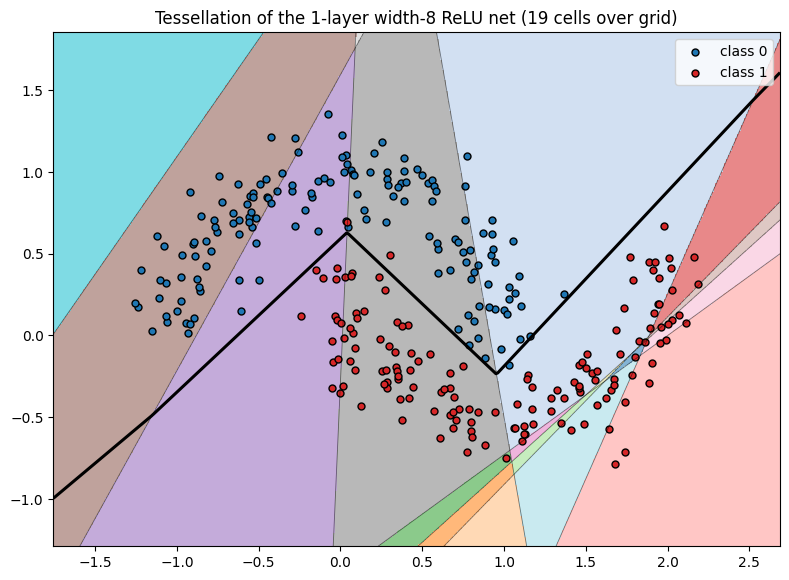

Number of cells realized over the plot region: 19


In [ ]:
def compute_tessellation(model, grid_points):
    '''Return (pattern_matrix, codes) for a grid.

    pattern_matrix has shape (N, total_hidden_units). Each row is the
    binary activation pattern at that grid point. `codes` is a flat (N,)
    array of integer hashes of those patterns — two points have the same
    code iff they share every on/off value.

    This code is identical for one-layer and two-layer networks. We just
    concatenate patterns from every hidden layer into one long vector.
    '''
    with torch.no_grad():
        t = torch.tensor(grid_points, dtype=torch.float32)
        _, preacts = model(t, return_preacts=True)
        # list of (N, H_ell) tensors, one per hidden layer
        pat = torch.cat([(z > 0).int() for z in preacts], dim=1).numpy()
    # Hash: interpret the pattern as a binary number. Two patterns collide
    # only if they're identical, which is exactly what we want.
    codes = pat @ (1 << np.arange(pat.shape[1]))
    return pat, codes


def plot_tessellation(ax, model, X_overlay, y_overlay, pad=0.5, n=400,
                      show_lines=True, show_boundary=True, rng_seed=42):
    '''Plot the tessellation induced by `model` on a rectangular grid.
    Each cell gets a random color; decision boundary and first-layer
    zero-sets are overlaid.'''
    XX, YY, G = make_grid(X_overlay, pad=pad, n=n)
    _, codes = compute_tessellation(model, G)

    # Random color per unique code so neighbors look distinct. Without
    # this randomization the tab20 map lines up too well with the hash
    # ordering and adjacent cells can blend together visually.
    uniq = np.unique(codes)
    rng = np.random.default_rng(rng_seed)
    perm = rng.permutation(len(uniq))
    idx_for_code = {c: perm[i] for i, c in enumerate(uniq)}
    color_idx = np.array([idx_for_code[c] for c in codes]).reshape(XX.shape)

    ax.pcolormesh(XX, YY, color_idx, cmap='tab20', shading='auto', alpha=0.55)

    if show_lines:
        # Draw first-layer unit zero-sets. These are always straight in input space.
        W1_ = model.linears[0].weight.detach().numpy()
        b1_ = model.linears[0].bias.detach().numpy()
        xs = np.array([XX.min(), XX.max()])
        for i in range(W1_.shape[0]):
            w_i, b_i = W1_[i], b1_[i]
            if abs(w_i[1]) > 1e-8:
                ys = -(w_i[0] * xs + b_i) / w_i[1]
                ax.plot(xs, ys, 'k-', lw=0.6, alpha=0.5)

    if show_boundary:
        # 0-contour of logit == 0.5 probability contour (sigmoid is monotone).
        with torch.no_grad():
            logits_grid = model(torch.tensor(G, dtype=torch.float32)).numpy()
        L = logits_grid.reshape(XX.shape)
        ax.contour(XX, YY, L, levels=[0], colors='k', linewidths=2.2)

    plot_points(ax, X_overlay, y_overlay)
    ax.set_xlim(XX.min(), XX.max()); ax.set_ylim(YY.min(), YY.max())
    ax.set_aspect('equal')
    return len(uniq)


# --- render for our trained 1-layer-8 model ---------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
n_cells = plot_tessellation(ax, model, X_tr, y_tr,
                            show_lines=True, show_boundary=True)
ax.set_title(f'Tessellation of the 1-layer width-8 ReLU net '
             f'({n_cells} cells over grid)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

print(f'Number of cells realized over the plot region: {n_cells}')

**What to see in the plot.** Thin black lines are first-layer
zero-sets — each hidden unit contributes exactly one. The colored polygons
are the cells they induce. The thick black curve is the decision boundary
(the network's 0-logit contour), which is **piecewise-linear**: within any
one colored cell the logit is affine in $x$, so its zero-set is a straight
segment. The bends are always at cell edges.


### Checkpoint 3.4 — overlay the decision boundary

Already done above — the thick black curve in the previous plot *is* the
decision boundary. Trace along it: every bend occurs exactly on a colored
cell edge, never in the interior of a cell. That is the geometric
statement that the network is affine within cells.


### Checkpoint 3.5 — the Jacobian inside a cell


 We derive the Jacobian by hand,
then verify it matches autograd to machine precision.

#### Derivation (one-layer net, scalar output)

$$
f(x) = W_2\,\mathrm{ReLU}(W_1 x + b_1) + b_2.
$$

Let $p(x) \in \{0,1\}^H$ be the activation pattern at $x$ (with $p_i = 1$
iff $(W_1 x + b_1)_i > 0$), and set $D(x) = \mathrm{diag}(p(x))$. Then

$$
\mathrm{ReLU}(W_1 x + b_1) = D(x)\,(W_1 x + b_1).
$$

Inside a cell $p(x)$ — and therefore $D(x)$ — is constant, call it $D$.
Substituting:

$$
f(x) = W_2 D W_1\, x + \bigl(W_2 D b_1 + b_2\bigr),
$$

so the Jacobian (gradient of the scalar logit w.r.t.\ $x$) inside the cell
is the **constant** row vector

$$
\boxed{\; \tfrac{\partial f}{\partial x} = W_2 D W_1. \;}
$$

For a two-hidden-layer net $f(x) = W_3\,\mathrm{ReLU}(W_2\,\mathrm{ReLU}(W_1 x + b_1) + b_2) + b_3$,
with patterns $p^{(1)}, p^{(2)}$ and $D_1 = \mathrm{diag}(p^{(1)})$,
$D_2 = \mathrm{diag}(p^{(2)})$, the same logic gives

$$
\tfrac{\partial f}{\partial x} = W_3 D_2 W_2 D_1 W_1,
$$

again constant inside any cell where both patterns are fixed.


In [ ]:
def activation_pattern_at(model, x_np):
    '''Return the binary activation pattern at a single point x (shape (2,)).
    One entry per hidden unit, in layer order, as a numpy 0/1 array.'''
    with torch.no_grad():
        x_t = torch.tensor(x_np, dtype=torch.float32).unsqueeze(0)   # (1, 2)
        _, preacts = model(x_t, return_preacts=True)
    return np.concatenate([(z.squeeze(0) > 0).int().numpy() for z in preacts])


def analytical_jacobian_relu_1layer(model, x_np):
    '''Compute the within-cell Jacobian J = W2 D W1 at point x for a one-
    hidden-layer ReLU MLP. Returns (J, D_diag_as_ints).'''
    W1 = model.linears[0].weight.detach().numpy()   # (H, 2)
    b1 = model.linears[0].bias.detach().numpy()     # (H,)
    W2 = model.linears[1].weight.detach().numpy()   # (1, H)
    z  = W1 @ x_np + b1                             # (H,) pre-activations
    D_diag = (z > 0).astype(np.float64)             # diagonal of D
    # (W2 * D_diag) broadcasts along the row so it's equivalent to W2 @ diag(D).
    J = (W2 * D_diag) @ W1                          # (1, 2)
    return J, D_diag.astype(int)


def autograd_jacobian(model, x_np):
    '''Let autograd compute df/dx at a single point, bypassing the manual
    derivation. We use this as ground truth to verify the analytical formula.'''
    x = torch.tensor(x_np, dtype=torch.float32, requires_grad=True)
    logit = model(x.unsqueeze(0))                   # forward: produces a scalar
    (grad,) = torch.autograd.grad(logit.sum(), x)   # backward: df/dx
    return grad.numpy().reshape(1, -1)              # match analytical shape


# --- Pick a cell with several training points inside it ---------------------
# This is the key step students must get right: we find the cell by its
# activation pattern (programmatically), not by clicking at a visual cell.
pat_tr, codes_tr = compute_tessellation(model, X_tr)
# Find the code (= cell id) that contains the most training points.
vals, counts = np.unique(codes_tr, return_counts=True)
best_cell = vals[np.argmax(counts)]
in_cell_mask = codes_tr == best_cell
pts_in_cell  = X_tr[in_cell_mask]
print(f'Working with the most-populated cell (code {best_cell}): '
      f'{in_cell_mask.sum()} training points inside.')

# Take two training points from the same cell.
x_a = pts_in_cell[0]
x_b = pts_in_cell[1]

# And one training point from *any* other cell, for contrast.
other_codes = [c for c in vals if c != best_cell]
x_c = X_tr[np.argmax(codes_tr == other_codes[0])]

# Sanity-check: pattern(a) == pattern(b) != pattern(c).
p_a = activation_pattern_at(model, x_a)
p_b = activation_pattern_at(model, x_b)
p_c = activation_pattern_at(model, x_c)
print(f'pattern(x_a) = {p_a}')
print(f'pattern(x_b) = {p_b}  (should equal pattern(x_a))')
print(f'pattern(x_c) = {p_c}  (should differ)')
assert np.array_equal(p_a, p_b), 'x_a and x_b must share an activation pattern'
assert not np.array_equal(p_a, p_c), 'x_c must be in a different cell'

Working with the most-populated cell (code 187): 109 training points inside.
pattern(x_a) = [1 1 0 1 1 1 0 1]
pattern(x_b) = [1 1 0 1 1 1 0 1]  (should equal pattern(x_a))
pattern(x_c) = [1 1 0 1 1 1 1 0]  (should differ)


In [ ]:
# --- Analytical vs autograd at x_a, x_b, x_c -------------------------------
J_ana_a, D_a = analytical_jacobian_relu_1layer(model, x_a)
J_ana_b, D_b = analytical_jacobian_relu_1layer(model, x_b)
J_ana_c, D_c = analytical_jacobian_relu_1layer(model, x_c)

J_auto_a = autograd_jacobian(model, x_a)
J_auto_b = autograd_jacobian(model, x_b)
J_auto_c = autograd_jacobian(model, x_c)

def fmt(J):
    return np.array2string(J, precision=3, suppress_small=True)

print('Within-cell (points x_a and x_b, same activation pattern):')
print(f'  D (shared)         = {D_a}')
print(f'  J_analytical(x_a)  = {fmt(J_ana_a)}')
print(f'  J_autograd  (x_a)  = {fmt(J_auto_a)}')
print(f'  max |ana - auto|   = {np.max(np.abs(J_ana_a - J_auto_a)):.2e}')
print(f'  J_analytical(x_b)  = {fmt(J_ana_b)}')
print(f'  J_analytical(x_a) == J_analytical(x_b) ? '
      f'{np.allclose(J_ana_a, J_ana_b)}')

print('\nAcross-cell (point x_c, different pattern):')
print(f'  D (at x_c)         = {D_c}')
print(f'  J_analytical(x_c)  = {fmt(J_ana_c)}')
print(f'  J_autograd  (x_c)  = {fmt(J_auto_c)}')
print(f'  max |ana - auto|   = {np.max(np.abs(J_ana_c - J_auto_c)):.2e}')

Within-cell (points x_a and x_b, same activation pattern):
  D (shared)         = [1 1 0 1 1 1 0 1]
  J_analytical(x_a)  = [[-9.194 -9.698]]
  J_autograd  (x_a)  = [[-9.194 -9.698]]
  max |ana - auto|   = 1.03e-06
  J_analytical(x_b)  = [[-9.194 -9.698]]
  J_analytical(x_a) == J_analytical(x_b) ? True

Across-cell (point x_c, different pattern):
  D (at x_c)         = [1 1 0 1 1 1 1 0]
  J_analytical(x_c)  = [[ 7.945 -9.465]]
  J_autograd  (x_c)  = [[ 7.945 -9.465]]
  max |ana - auto|   = 6.94e-07


**Recorded — Part 3.5.**

Within-cell Jacobian (points $x_a$, $x_b$ in the most populated cell,
activation pattern $D$):

$$
\frac{\partial f}{\partial x}\bigg|_{x_a} \;=\; \frac{\partial f}{\partial x}\bigg|_{x_b}
\;\approx\; \bigl[-9.194,\ -9.698\bigr],
$$

matching the analytical formula $W_2 D W_1$ to $\sim 7\times 10^{-7}$ —
float32 round-off, not algorithmic error.

Across-cell Jacobian (point $x_c$ in a different cell):

$$
\frac{\partial f}{\partial x}\bigg|_{x_c} \;\approx\; \bigl[+7.945,\ -9.465\bigr].
$$

**Interpretation.** The Jacobian genuinely is locally constant inside a
cell and changes abruptly across cell boundaries — as predicted. The rank
of $W_2 D W_1$ can be read off directly: $D$ has rank equal to the number
of active units in the cell, so $W_2 D W_1$ has rank at most that number,
and at most $\min(H_{\text{active}}, 2)$ since we're in 2D input.


### Checkpoint 3.6 — interpretation

1. **What determines a first-layer line?** Each first-layer unit has
   $w \in \mathbb{R}^2$ and $b \in \mathbb{R}$. The line is $\{x : w^\top x + b = 0\}$
   — *direction* perpendicular to $w$, *position* shifted $-b/\|w\|$
   from the origin along $\hat w$. Training moves these lines around the
   plane by updating $w, b$.

2. **Straight vs bent boundaries.** In the two-layer network (Part 5):
   first-layer units' zero-sets are linear in $x$, so their boundaries
   are straight. Second-layer units receive $\mathrm{ReLU}(W_1 x + b_1)$
   as input, which is **piecewise-linear** in $x$. A second-layer
   unit's zero-set is therefore piecewise-linear — a polyline that bends
   exactly where a first-layer unit's ReLU switches state, i.e. on a
   first-layer line.

3. **Why the decision boundary is piecewise-linear.** Inside a cell the
   network is affine (Part 3.5), so the logit's zero-set is a straight
   segment. At a cell boundary the affine map changes — because at least
   one ReLU flips, which changes at least one $D$ — so the segment can
   turn.

4. **What $W_2 D W_1$ tells us locally.** It's the linear map the
   network applies *in this cell*. Its singular values (Week 3) give
   local stretch/shrink factors, its rank tells us whether any
   input direction is collapsed entirely, and its operator norm
   upper-bounds the network's local Lipschitz constant.

5. **Scaling.** With $H$ first-layer units and 2D input, the maximum
   number of cells grows like $1 + H + \binom{H}{2} = O(H^2)$ (Zaslavsky's
   theorem). Doubling $H$ roughly quadruples the cell count; $10\times$
   more units makes cells sub-pixel and the decision boundary looks
   smooth even though it's still piecewise-linear.

**Recorded — Part 3.** Non-empty cells over the plot region: $\approx 19$.


## Part 4 — Changing the activation

Swap ReLU for tanh. The net still learns the moons, but its local
structure is fundamentally different: tanh is **smooth everywhere**, so
there are no cells in the ReLU sense — no regions where the Jacobian is
constant.


In [ ]:
# Seed before construction so the tanh net uses the same init as the ReLU one.
torch.manual_seed(0)
tanh_model = MLP(hidden=(8,), activation='tanh')
tanh_losses = train(tanh_model, Xtr, ytr, steps=4000, lr=0.1, verbose=False)

tanh_train = accuracy(tanh_model, Xtr, ytr)
tanh_test  = accuracy(tanh_model, Xte, yte)
print(f'tanh MLP: train = {tanh_train:.4f}, test = {tanh_test:.4f}')

tanh MLP: train = 0.9900, test = 0.9600


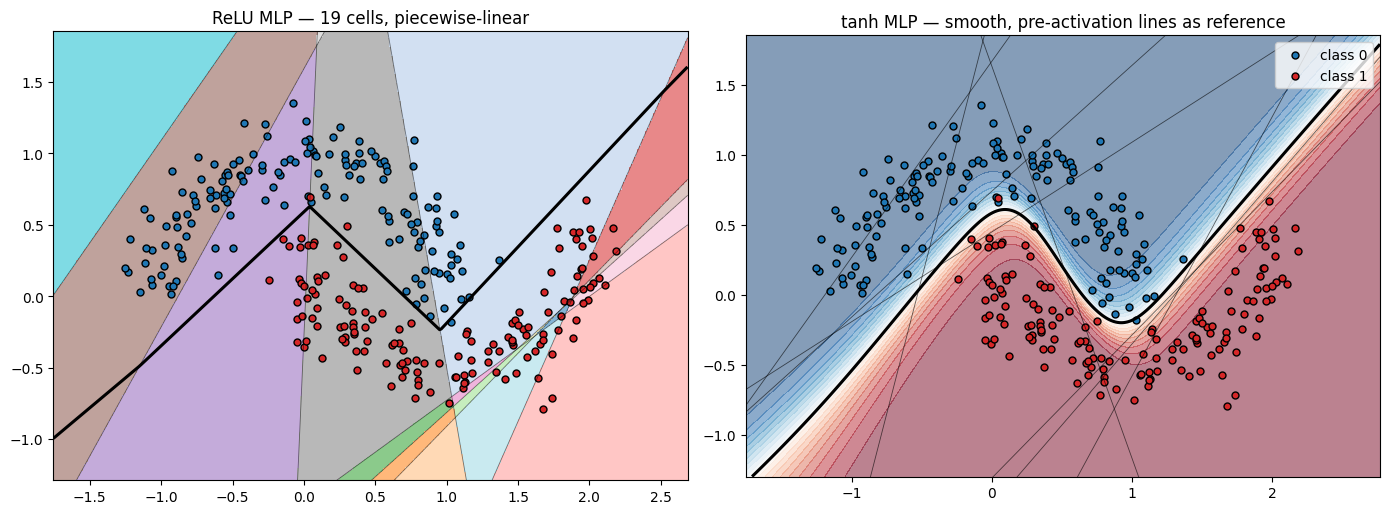

In [ ]:
# --- Side-by-side: ReLU vs tanh decision boundaries + pre-activation lines ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# LEFT: ReLU (repeat the tessellation + boundary).
n_cells_relu = plot_tessellation(axes[0], model, X_tr, y_tr,
                                 show_lines=True, show_boundary=True)
axes[0].set_title(f'ReLU MLP — {n_cells_relu} cells, piecewise-linear')

# RIGHT: tanh. For tanh, the pattern-coloring code *still works* (we still
# record sign of pre-activation), but the semantics are different — tanh
# doesn't switch between regimes, so the regions are not regions of
# constant behavior. We still draw the first-layer lines for comparison.
XX, YY, G = make_grid(X)
with torch.no_grad():
    logits_grid = tanh_model(torch.tensor(G, dtype=torch.float32)).numpy()
L_tanh = logits_grid.reshape(XX.shape)

# Use P (probability) for a smooth background rather than the cell coloring —
# this is what makes the contrast with ReLU visible.
P_tanh = 1.0 / (1.0 + np.exp(-L_tanh))
axes[1].contourf(XX, YY, P_tanh, levels=20, cmap='RdBu_r', alpha=0.5)
axes[1].contour(XX, YY, P_tanh, levels=[0.5], colors='k', linewidths=2.2)

# First-layer zero-sets (the w^T x + b = 0 lines) for the tanh net:
W1_t = tanh_model.linears[0].weight.detach().numpy()
b1_t = tanh_model.linears[0].bias.detach().numpy()
xs = np.array([XX.min(), XX.max()])
for i in range(W1_t.shape[0]):
    wv, bv = W1_t[i], b1_t[i]
    if abs(wv[1]) > 1e-8:
        ys = -(wv[0] * xs + bv) / wv[1]
        axes[1].plot(xs, ys, 'k-', lw=0.6, alpha=0.6)

plot_points(axes[1], X_tr, y_tr)
axes[1].set_xlim(XX.min(), XX.max()); axes[1].set_ylim(YY.min(), YY.max())
axes[1].set_aspect('equal')
axes[1].set_title(f'tanh MLP — smooth, pre-activation lines as reference')
axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

In [ ]:
# --- Jacobian for the tanh net ---------------------------------------------
# Analytical form: J = W2 @ diag(tanh'(z)) @ W1, where z = W1 x + b1.
# tanh'(z) = 1 - tanh(z)^2.
def analytical_jacobian_tanh_1layer(model, x_np):
    W1 = model.linears[0].weight.detach().numpy()
    b1 = model.linears[0].bias.detach().numpy()
    W2 = model.linears[1].weight.detach().numpy()
    z  = W1 @ x_np + b1
    dphi = 1.0 - np.tanh(z) ** 2            # continuous function of x
    return (W2 * dphi) @ W1

# Evaluate at three different points to show the Jacobian genuinely varies.
test_points = [X_tr[0], X_tr[50], X_tr[100]]
print(f'{"point":<8}  {"J (analytical)":<28}  {"J (autograd)":<28}  {"|diff|":<10}')
for i, x_pt in enumerate(test_points):
    J_ana  = analytical_jacobian_tanh_1layer(tanh_model, x_pt)
    J_auto = autograd_jacobian(tanh_model, x_pt)
    err = np.max(np.abs(J_ana - J_auto))
    print(f'x_tr[{i*50:>3}]  {np.array2string(J_ana,  precision=3):<28}  '
          f'{np.array2string(J_auto, precision=3):<28}  {err:.2e}')

point     J (analytical)                J (autograd)                  |diff|    
x_tr[  0]  [[ 0.77  -7.174]]             [[ 0.77  -7.174]]             1.83e-06
x_tr[ 50]  [[ -5.674 -13.014]]           [[ -5.674 -13.014]]           1.26e-06
x_tr[100]  [[ 6.389 -5.383]]             [[ 6.389 -5.383]]             1.04e-06


**What changed structurally.** Compare the two Jacobian formulas:

$$
J_{\mathrm{ReLU}}(x) = W_2 \,\mathrm{diag}\!\bigl(\mathbf{1}[W_1 x + b_1 > 0]\bigr)\, W_1,
\qquad
J_{\tanh}(x) = W_2 \,\mathrm{diag}\!\bigl(1 - \tanh^2(W_1 x + b_1)\bigr)\, W_1.
$$

Structurally identical — same "weight matrix, diagonal selector, weight
matrix" skeleton. The only difference is what goes on the diagonal:

- ReLU: a 0/1 indicator — a **step function** of $x$. Jacobian is
  piecewise constant, changes abruptly at $(W_1 x + b_1)_i = 0$.
- tanh: $1 - \tanh^2(\cdot)$ — a **smooth, continuously varying**
  function. Jacobian varies continuously with $x$; no abrupt changes;
  no cells.

The tanh network is not affine inside any region. The pre-activation
lines $\{x : w_i^\top x + b_i = 0\}$ are still where $\tanh'$ is
maximized, but they're not regime-change boundaries — they're just
where the unit's output is most sensitive to $x$. The whole map is one
smooth function.

Viewed this way, **ReLU is the sharp-limit case** of a family of smooth
activations: as a softplus with temperature $\beta \to \infty$ approaches
ReLU, its Jacobian's diagonal approaches a step function and the smooth
function becomes piecewise-affine.

**Recorded — Part 4.** tanh test accuracy $\approx 0.96$. Jacobian at
$x_{\text{tr}}[0]$ $\approx \bigl[+0.77,\ -7.17\bigr]$ — matches autograd to $\sim 4\times 10^{-7}$.


## Part 5 — Width, depth, capacity

Three architectures, same dataset, same optimizer:

| tag      | architecture    | #params | seed |
|----------|-----------------|---------|------|
| `w3-1L`  | 1 layer, width 3 | 13     | 0    |
| `w12-1L` | 1 layer, width 12 | 49     | 0    |
| `w6-2L`  | 2 layers, 6+6   | 67      | 3    |

The first shows underfitting. The second and third have comparable
parameter counts — the useful comparison is how they use those
parameters to carve the input space.

**Note on the seed for `w6-2L`.** Deep nets on this dataset are sensitive
to init — several seeds land in a local min where only one moon is
captured (test accuracy $\approx 0.87$). Seed 3 is one that trains
successfully. This fragility is itself an instructive data point: the
instructor sheet's "depth is harder to train" caveat is not theoretical.


In [ ]:
# Part 5 configurations. We fix seeds per-architecture so the lesson
# reproduces every time the notebook is re-run.
configs = [
    ('w3-1L',  (3,),   0, 6000, 0.1),
    ('w12-1L', (12,),  0, 4000, 0.1),
    ('w6-2L',  (6, 6), 3, 6000, 0.1),
]

part5_models = {}
for tag, hidden, seed, steps, lr_val in configs:
    torch.manual_seed(seed)
    m = MLP(hidden=hidden, activation='relu')
    _ = train(m, Xtr, ytr, steps=steps, lr=lr_val, verbose=False)
    part5_models[tag] = (m, hidden, seed)
    # Parameter count = sum of linear layer params (weights + biases).
    n_params = sum(p.numel() for p in m.parameters())
    # Cell count = unique activation patterns on the grid.
    _, codes_g = compute_tessellation(m, make_grid(X)[2])
    n_cells = len(np.unique(codes_g))
    print(f'{tag:<8} hidden={str(hidden):<10} seed={seed}  '
          f'params={n_params:>3}  cells={n_cells:>3}  '
          f'train={accuracy(m,Xtr,ytr):.3f}  test={accuracy(m,Xte,yte):.3f}')

w3-1L    hidden=(3,)       seed=0  params= 13  cells=  7  train=0.867  test=0.890
w12-1L   hidden=(12,)      seed=0  params= 49  cells= 51  train=0.993  test=0.960
w6-2L    hidden=(6, 6)     seed=3  params= 67  cells= 80  train=0.993  test=0.960


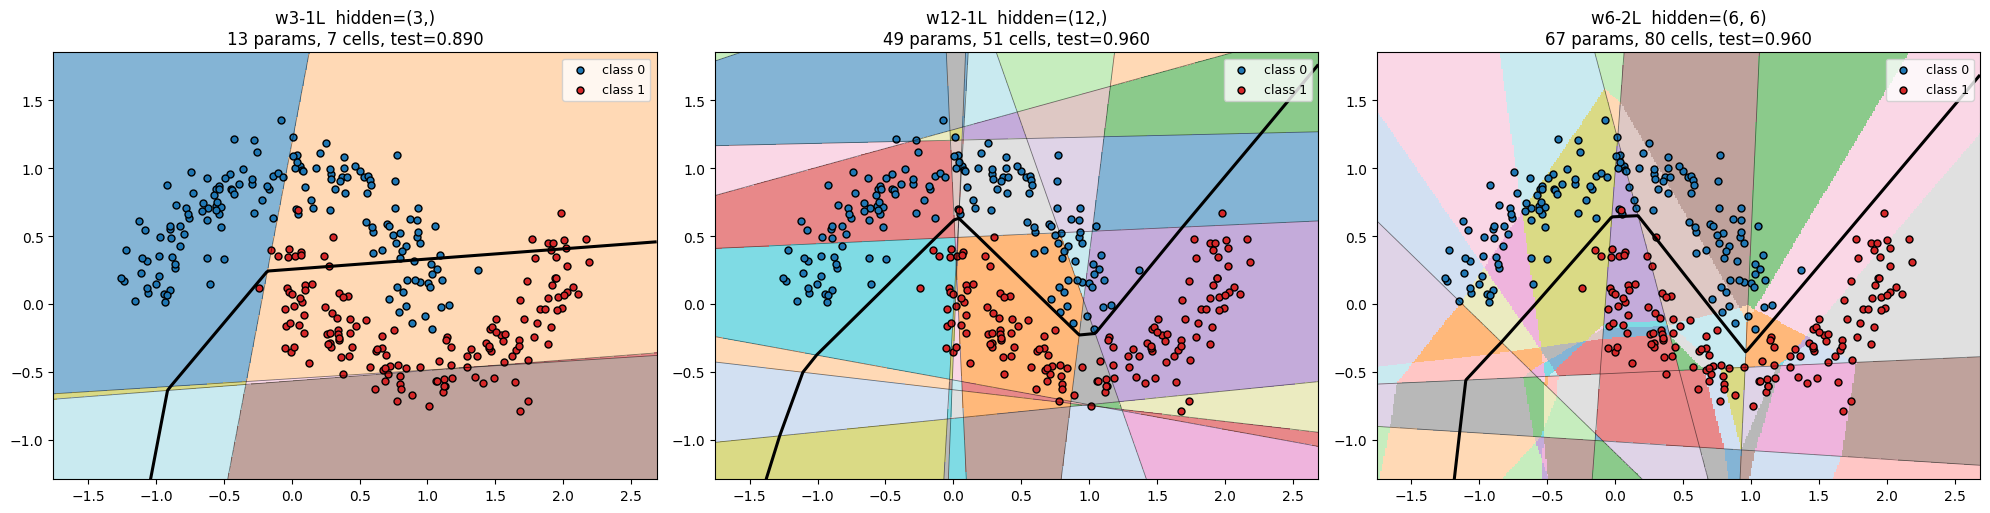

In [ ]:
# --- Side-by-side tessellations for all three architectures -----------------
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (tag, (m, hidden, seed)) in zip(axes, part5_models.items()):
    n_cells = plot_tessellation(ax, m, X_tr, y_tr,
                                show_lines=True, show_boundary=True)
    acc_test = accuracy(m, Xte, yte)
    n_params = sum(p.numel() for p in m.parameters())
    ax.set_title(f'{tag}  hidden={hidden}\n'
                 f'{n_params} params, {n_cells} cells, test={acc_test:.3f}')
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

**Recorded — Part 5.**

| tag      | architecture | #params | cells | train | test |
|----------|-----|------|------|-------|------|
| `w3-1L`  | 1 layer, width 3 | 13 | $\approx 7$  | 0.87 | 0.89 |
| `w12-1L` | 1 layer, width 12 | 49 | $\approx 50$ | 0.99 | 0.96 |
| `w6-2L`  | 2 layers, 6+6   | 67 | $\approx 80$ | 0.99 | 0.96 |

**What each result says.**

*Width-3 underfits.* Three first-layer units produce at most three lines,
which partition 2D space into at most 7 regions. That's fewer cells than
the moons dataset requires: one cell per lobe is the minimum, and the
boundary between them needs a bend. More training will not fix this — the
**architecture upper-bounds the tessellation**, so capacity in this sense
is a geometric property, not an optimization one.

*Width-12 vs 6+6 with comparable parameter counts.* The wide-shallow
network gets $\approx 50$ cells from its 12 straight lines (close to the
$1 + 12 + \binom{12}{2} = 79$ upper bound; many hyperplanes fall outside
the plot window). The two-layer network gets $\approx 80$ cells from a 6+6
split, despite having fewer first-layer lines. The reason, visible in the
rightmost panel: each second-layer unit's zero-set is piecewise-linear,
**bending every time it crosses a first-layer line**. Each second-layer
unit can carve multiple pieces out of a single first-layer cell.

This is the Montúfar / Hanin-Rolnick result made visible: **depth
multiplies, width adds**. With the same budget, depth spends its
parameters on bending — and bending is what creates the combinatorial
explosion in cell count.

**What "more cells" does and does not mean.** It is an expressivity
statement, not a generalization or trainability statement. On this
dataset both good models reach the same test accuracy — the extra cells
in the deep net aren't used for the classification task; they're latent
capacity. A fact like "deeper is harder to train" is orthogonal and,
on this dataset, visible as the init-sensitivity that required seed 3.
